<a href="https://colab.research.google.com/github/yfpang7/dataScience_Practice/blob/main/vega_altair.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [184]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import numpy as np
import plotly.io as pio
from vega_datasets import data
import altair as alt

!pip install vl-convert-python
alt.renderers.enable('svg')
pio.renderers.default = 'colab'

In [185]:
# import the data
cars_data = data.cars()

In [186]:
cars_data.head()

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA


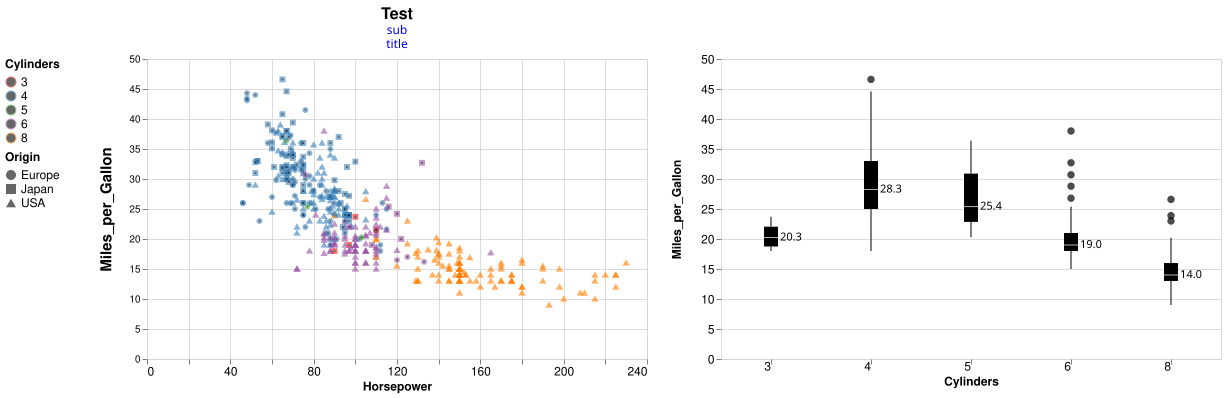

In [187]:
import altair as alt
from vega_datasets import data

# Load the dataset
cars_data = data.cars()

# Define the title with subtitle
title = alt.TitleParams(
    'Test', subtitle=['sub', 'title'], anchor='middle', subtitleColor='Blue'
)

# Scatter plot
scatter_plot = (
    alt.Chart(cars_data, title=title)
    .mark_point(filled=False, opacity=0.6, size=15)
    .encode(
        x=alt.X('Horsepower:Q', axis=alt.Axis(title='Horsepower')),
        y=alt.Y(
            'Miles_per_Gallon:Q',
            axis=alt.Axis(title='Miles_per_Gallon', titleFontSize=15, labelFontSize=10),
            scale=alt.Scale(domain=[0, 50]),
        ),
        color=alt.Color('Cylinders:N', legend=alt.Legend(orient='left'), scale=alt.Scale(scheme='set1')),
        shape=alt.Shape('Origin:N', legend=alt.Legend(orient='left')),
        tooltip=['Name:N', 'Cylinders:N']
    )
    .properties(width=500, height=300)
    .interactive()
)

# Box plot with median annotations
box_plot = (
    alt.Chart(cars_data)
    .mark_boxplot()
    .encode(
        x=alt.X('Cylinders:N'),
        y=alt.Y('Miles_per_Gallon:Q')
    )
    .properties(width=500, height=300)
)

# Calculate the median for each cylinder group
median_text = (
    alt.Chart(cars_data)
    .mark_text(dx=20, color='black')  # Position the text slightly above the box plot
    .encode(
        x=alt.X('Cylinders:N', axis=alt.Axis(labelAngle=0)),
        y=alt.Y('median(Miles_per_Gallon):Q'),
        text=alt.Text('median(Miles_per_Gallon):Q', format='.1f')  # Format to 1 decimal place
    )
)

# Combine the scatter plot and the box plot with median annotations
final_chart = scatter_plot | (box_plot + median_text)
final_chart


In [188]:
# to replicate this on Plotly express
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from vega_datasets import data

# Load the dataset
cars_data = data.cars()

# Scatter plot
scatter_fig = px.scatter(
    cars_data,
    x='Horsepower',
    y='Miles_per_Gallon',
    color='Cylinders',
    symbol='Origin',
    size_max=15,
    opacity=0.6,
    title='Test<br><sup>sub title</sup>'
)

# Update layout for scatter plot
scatter_fig.update_layout(
    xaxis_title='Horsepower',
    yaxis_title='Miles per Gallon',
    yaxis=dict(range=[0, 50], title_font=dict(size=15), tickfont=dict(size=10)),
    title_x=0.5,
    legend=dict(x=-0.3, y=0.5, title_text="Legend"),  # Move legend to the left
    title_font_color="blue"
)

# Box plot with median annotations
box_fig = px.box(
    cars_data,
    x='Cylinders',
    y='Miles_per_Gallon',
    points='all'  # Show all points to match Altair's interactivity
)

# Calculate median values for each cylinder group for annotation
median_values = cars_data.groupby('Cylinders')['Miles_per_Gallon'].median().reset_index()

# Add median annotations
for i, row in median_values.iterrows():
    box_fig.add_trace(
        go.Scatter(
            x=[row['Cylinders']],
            y=[row['Miles_per_Gallon']],
            text=f"{row['Miles_per_Gallon']:.1f}",
            mode="text",
            textposition="top center",
            showlegend=False
        )
    )

# Set layout for box plot
box_fig.update_layout(
    xaxis_title='Cylinders',
    yaxis_title='Miles per Gallon',
)

# Combine scatter and box plot in a subplot
# Create subplot figure
combined_fig = make_subplots(rows=1, cols=2, subplot_titles=("Scatter Plot", "Box Plot with Medians"))

# Add scatter plot
for trace in scatter_fig['data']:
    combined_fig.add_trace(trace, row=1, col=1)

# Add box plot with median annotations
for trace in box_fig['data']:
    combined_fig.add_trace(trace, row=1, col=2)

# Set combined layout
combined_fig.update_layout(
    width=1000, height=400,
    title_text='Combined Plot',
    template='ggplot2',
    legend=dict(
        orientation="v",  # Vertical orientation
        yanchor="top",  # Anchor top of legend
        y=0.9,  # Position legend near the top
        xanchor="left",  # Anchor legend to the left
        x=0.1,  # Adjust horizontal position as needed
        title_text="Legend"
    )
)

combined_fig.show()

combined_fig.show()



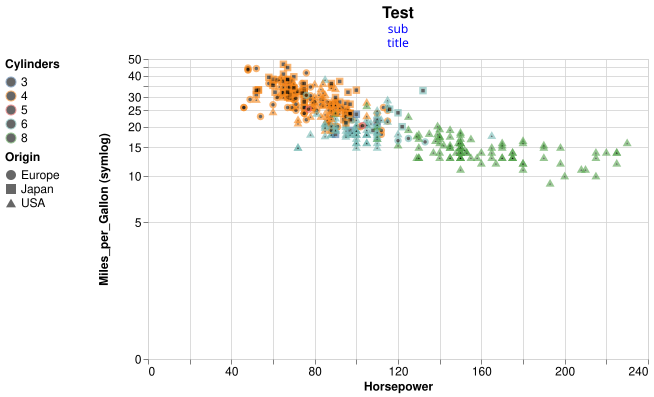

In [189]:
# plot the scatter plot
# title = alt.TitleParams('Test', subtitle='sub title', anchor='middle')
title = alt.TitleParams('Test', subtitle=['sub', 'title'], anchor='middle', subtitleColor='Blue') # this one is title breakpoint

(
    alt.Chart(
        cars_data,
        title=title,
    )
    .mark_point(filled=False, opacity=0.6)
    .encode(
        x=alt.X('Horsepower:Q', axis=alt.Axis(title='Horsepower')),
        # Move the scale definition to alt.Y
        # y=alt.Y('Miles_per_Gallon:Q', axis=alt.Axis(title='Miles_per_Gallon (log10)'), scale=alt.Scale(type='log')),
        y=alt.Y('Miles_per_Gallon:Q', axis=alt.Axis(title='Miles_per_Gallon (symlog)'), scale=alt.Scale(type='symlog')),
        color=alt.Color('Cylinders:N', legend=alt.Legend(orient='left')),
        shape=alt.Shape('Origin:N', legend=alt.Legend(orient='left'))
    )
    .properties(width=500, height=300)
    .interactive()
    .encode(tooltip=['Name:N', 'Cylinders:N'])

)

/tmp/ipython-input-830926158.py:15: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.



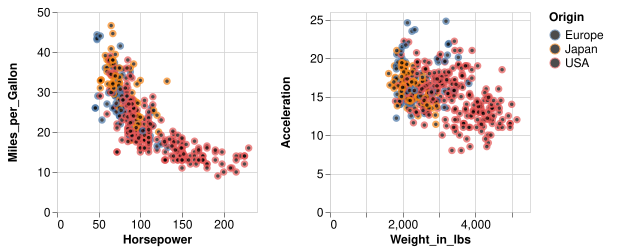

In [190]:
# selection by adding brush

# brush = alt.selection(type='interval')
brush = alt.selection_interval(resolve='intersect')

points = (
    alt.Chart(cars_data)
    .mark_point()
    .encode(
        x=alt.X('Horsepower:Q', axis=alt.Axis(title='Horsepower')),
        y=alt.Y('Miles_per_Gallon:Q', axis=alt.Axis(title='Miles_per_Gallon')),
        color=alt.condition(brush, if_true='Origin:N', if_false=alt.value('lightgray')),
        tooltip=['Name:N', 'Cylinders:N']
    )
    .add_selection(brush)
)

points | points.encode(x=alt.X('Weight_in_lbs:Q'), y=alt.Y('Acceleration:Q'))


/tmp/ipython-input-4197918447.py:50: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.



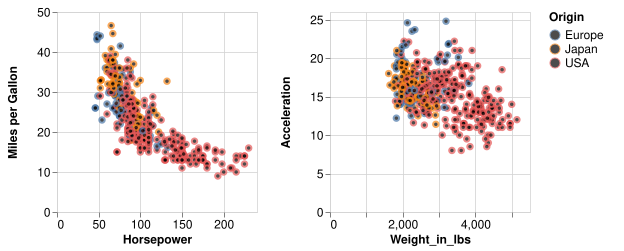

In [191]:
import altair as alt

# Setting up a ggplot2-like theme in Altair
ggplot2_theme = {
    'config': {
        'background': 'white',
        'title': {'fontSize': 16, 'font': 'Helvetica', 'color': 'black', 'anchor': 'start'},
        'axis': {
            'domain': False,
            'tickColor': 'gray',
            'labelFont': 'Helvetica',
            'labelFontSize': 12,
            'titleFont': 'Helvetica',
            'titleFontSize': 12,
            'titleColor': 'black',
            'gridColor': 'lightgray',
            'gridWidth': 0.8
        },
        'legend': {
            'labelFont': 'Helvetica',
            'labelFontSize': 12,
            'titleFont': 'Helvetica',
            'titleFontSize': 12
        },
        'mark': {
            'color': 'black',
            'fill': 'black',
            'strokeWidth': 1
        }
    }
}

# Apply theme
alt.themes.register('ggplot2_theme', lambda: ggplot2_theme)
alt.themes.enable('ggplot2_theme')

# Selection brush
brush = alt.selection_interval(resolve='intersect')

# Define the main chart with the ggplot2-like theme
points = (
    alt.Chart(cars_data)
    .mark_point()
    .encode(
        x=alt.X('Horsepower:Q', axis=alt.Axis(title='Horsepower')),
        y=alt.Y('Miles_per_Gallon:Q', axis=alt.Axis(title='Miles per Gallon')),
        color=alt.condition(brush, 'Origin:N', alt.value('lightgray')),
        tooltip=['Name:N', 'Cylinders:N']
    )
    .add_selection(brush)
)

# Combine both charts with ggplot2-like theme applied
(points | points.encode(x=alt.X('Weight_in_lbs:Q'), y=alt.Y('Acceleration:Q')))


In [192]:
iris_dataset = data.iris()

iris_dataset.head()

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [193]:
iris_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepalLength  150 non-null    float64
 1   sepalWidth   150 non-null    float64
 2   petalLength  150 non-null    float64
 3   petalWidth   150 non-null    float64
 4   species      150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


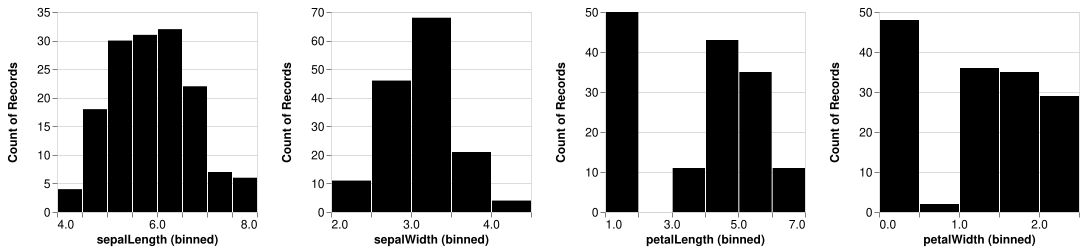

In [194]:
numerical_columns = iris_dataset.select_dtypes(include=['number']).columns.to_list()

(
    alt.Chart(iris_dataset)
    .mark_bar()
    .encode(
        x=alt.X(alt.repeat(), type='quantitative', bin=alt.Bin(maxbins=10)),
        y='count()',
    )
    .properties(width=200, height=200)

).repeat(numerical_columns)

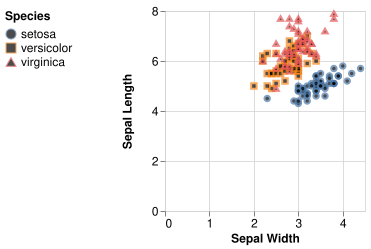

In [195]:
point = (
    alt.Chart(iris_dataset)
    .mark_point()
    .encode(
        x=alt.X('sepalWidth', title='Sepal Width'),
        y=alt.Y('sepalLength', title='Sepal Length'),
        shape=alt.Shape('species:N', title='Species', legend=alt.Legend(orient='left')),
        color=alt.Color('species:N', title='Species', legend=alt.Legend(orient='left')),
    )
)

point

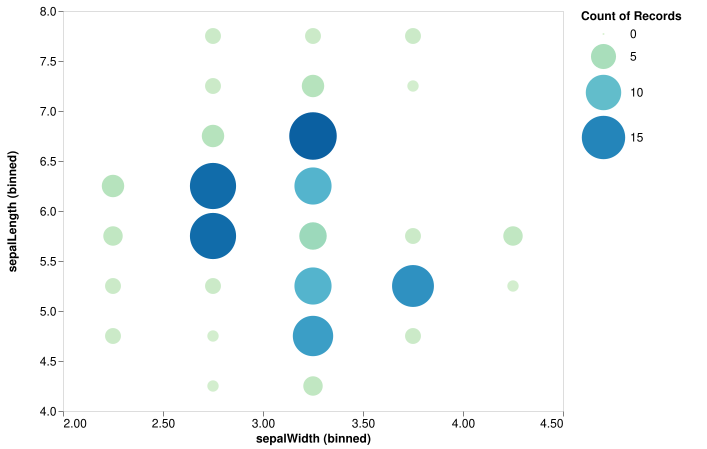

In [196]:
# heat map
(
    alt.Chart(iris_dataset)
    .mark_circle()
    .encode(
        alt.X('sepalWidth:Q', bin=alt.Bin(maxbins=10)),
        alt.Y('sepalLength:Q', bin=alt.Bin(maxbins=10)),
        color=alt.Color('count()', scale=alt.Scale(scheme='greenblue')),
        size=alt.Size('count()', scale=alt.Scale(scheme='greenblue')),
    )
    .properties(width=500, height=400)


)

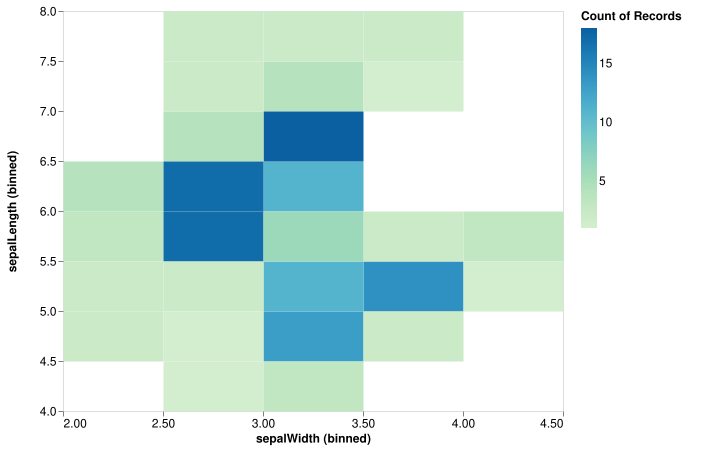

In [197]:
# heat map
(
    alt.Chart(iris_dataset)
    .mark_rect()
    .encode(
        alt.X('sepalWidth:Q', bin=alt.Bin(maxbins=10)),
        alt.Y('sepalLength:Q', bin=alt.Bin(maxbins=10)),
        color=alt.Color('count()', scale=alt.Scale(scheme='greenblue')),
        size=alt.Size('count()', scale=alt.Scale(scheme='greenblue')),
    )
    .properties(width=500, height=400)


)

In [198]:
import plotly.express as px

# Assuming iris_dataset is your DataFrame
fig = px.density_heatmap(
    data_frame=iris_dataset,
    x='sepalWidth',
    y='sepalLength',
    nbinsx=10,          # Number of bins along x-axis
    nbinsy=10,          # Number of bins along y-axis
    color_continuous_scale='RdBu_R',  # Color scale to match the scheme
    text_auto=True
)

# Customize layout
fig.update_layout(
    width=500,
    height=400,
    coloraxis_colorbar=dict(
        title='Count'
    ),
    font=dict(size=8)
)

fig.show()


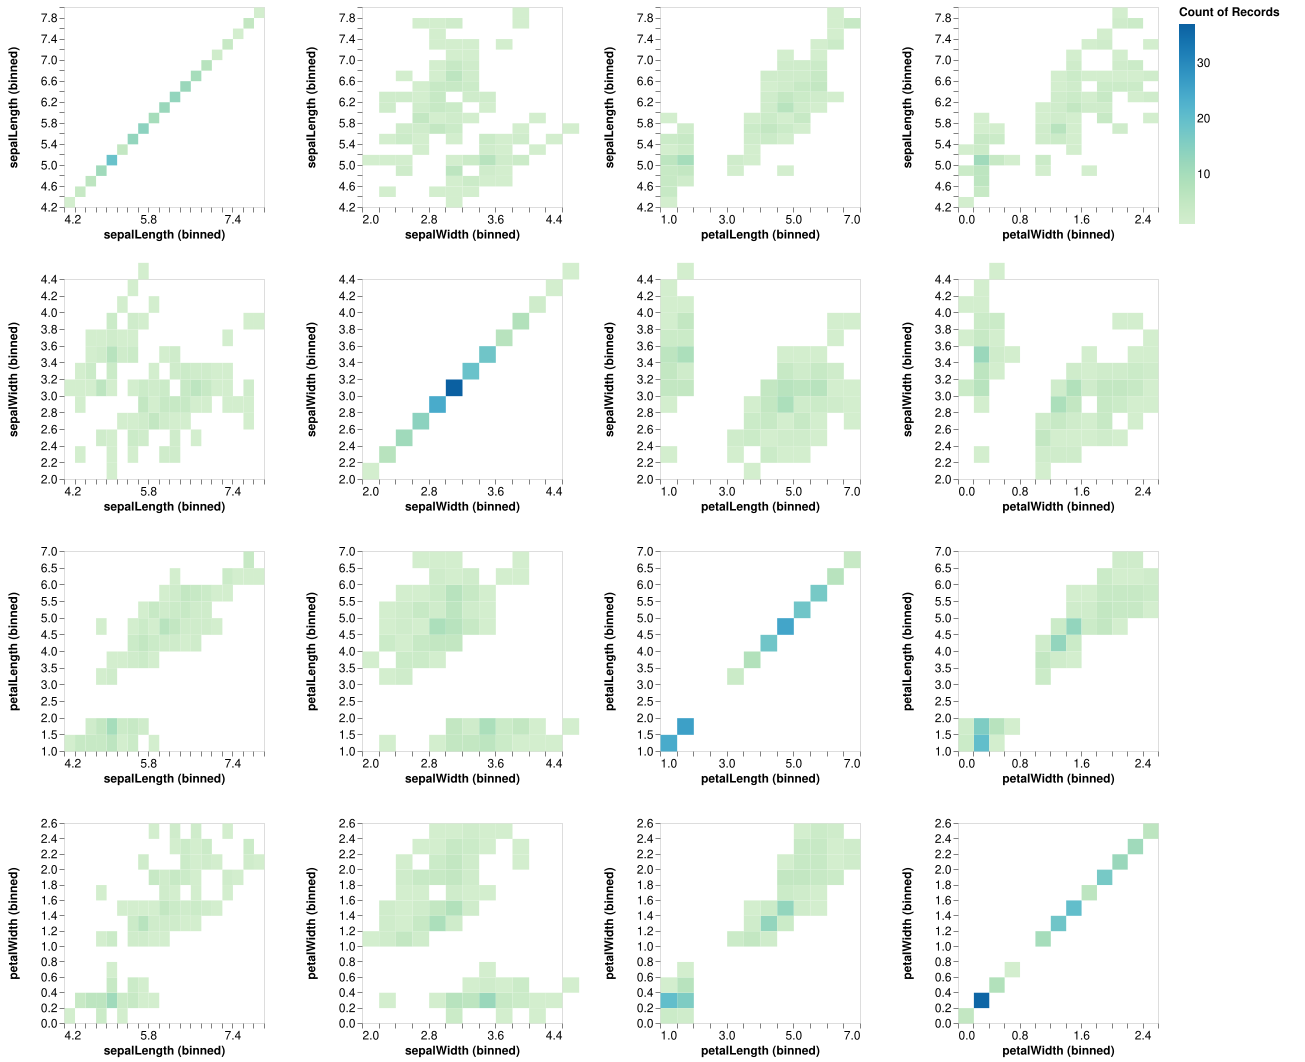

In [199]:
numerical_columns = iris_dataset.select_dtypes(include=['number']).columns.to_list()


(
    alt.Chart(iris_dataset)
    .mark_rect()
    .encode(
        x=alt.X(alt.repeat('column'), type='quantitative', bin=alt.Bin(maxbins=20)),
        y=alt.Y(alt.repeat('row'), type='quantitative', bin=alt.Bin(maxbins=20)),
        color=alt.Color('count()', scale=alt.Scale(scheme='greenblue')),
    )
    .properties(width=200, height=200)
    .repeat(column=numerical_columns, row=numerical_columns)
)

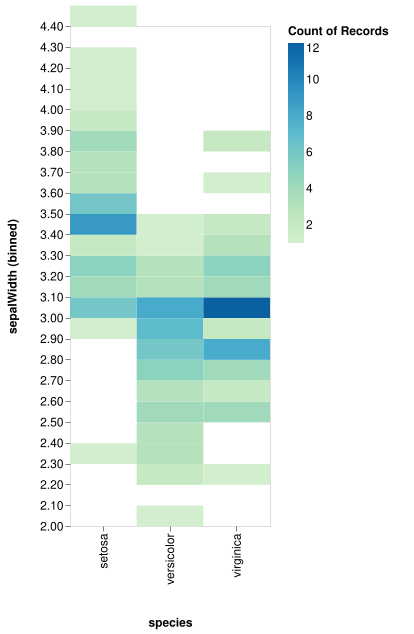

In [200]:
(
    alt.Chart(iris_dataset)
    .mark_rect()
    .encode(
        x=alt.X('species:N'),
        y=alt.Y('sepalWidth:Q', bin=alt.Bin(maxbins=30), ),
        color=alt.Color('count()', scale=alt.Scale(scheme='greenblue')),
    )
    .properties(width=200, height=500)
)

In [201]:
iris_dataset.head()

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


/tmp/ipython-input-2692547078.py:3: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.

/tmp/ipython-input-2692547078.py:20: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.



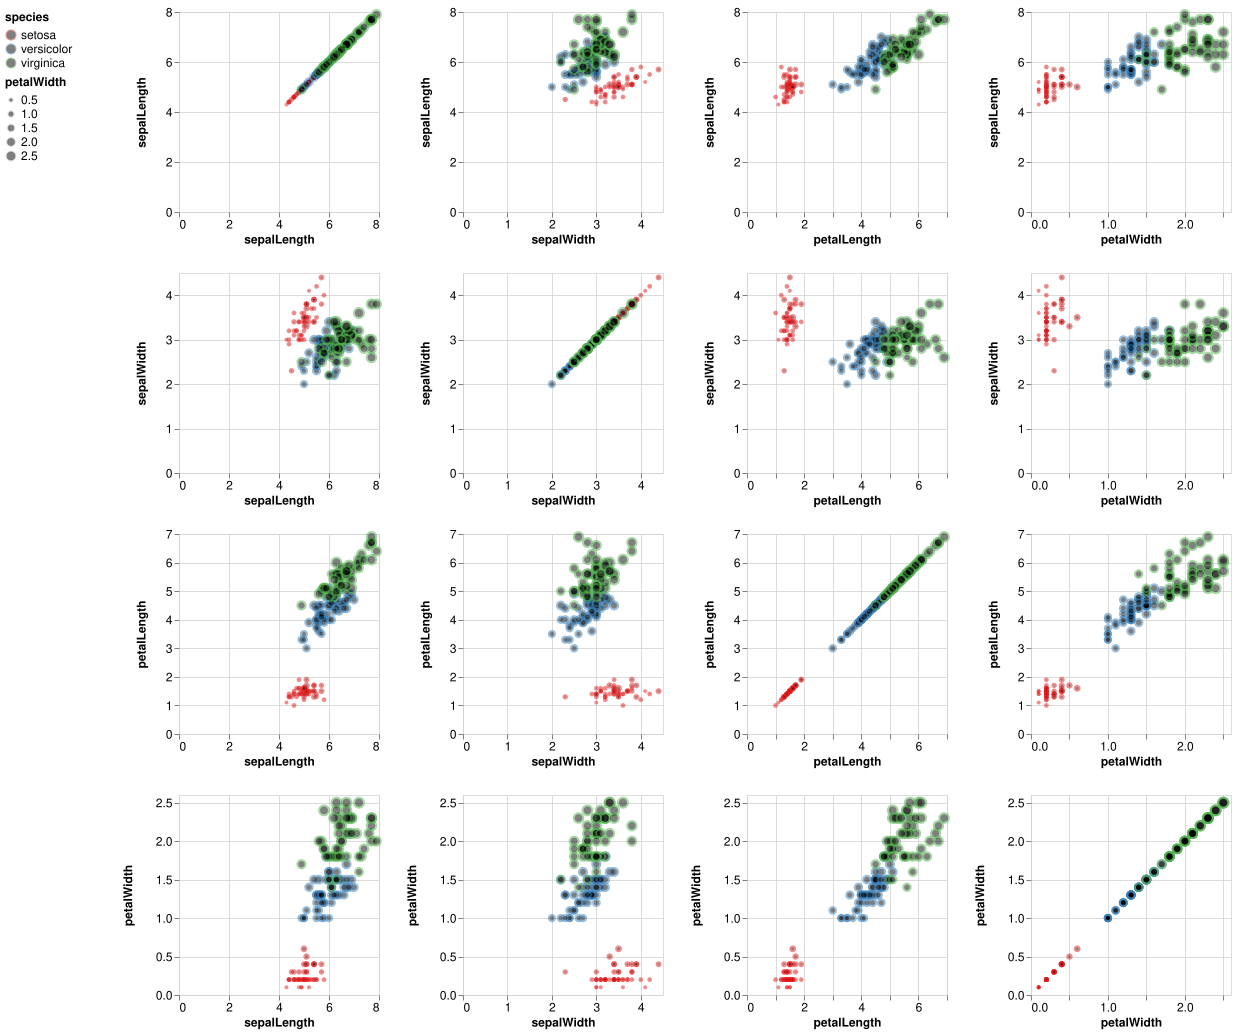

In [202]:
# scatter matrix

brush = alt.selection(type='interval')
# brush = alt.selection_interval(resolve='intersect')

scatter_matrix = (
    alt.Chart(iris_dataset)
    .mark_point(opacity=0.5)
    .encode(
        x=alt.X(alt.repeat('column'), type='quantitative',),
        y=alt.Y(alt.repeat('row'), type='quantitative'),
        color=alt.condition(brush, 'species:N', alt.value('lightgrey'), legend=alt.Legend(orient='left'), scale=alt.Scale(scheme='set1')),
        size=alt.Size('petalWidth', legend=alt.Legend(orient='left'), scale=alt.Scale(range=[0,100])),
    )
    .properties(width=200, height=200)
    .repeat(
        row=['sepalLength', 'sepalWidth', 'petalLength', 'petalWidth'],
        column=['sepalLength', 'sepalWidth', 'petalLength', 'petalWidth'],
    )
).add_selection(brush)


scatter_matrix

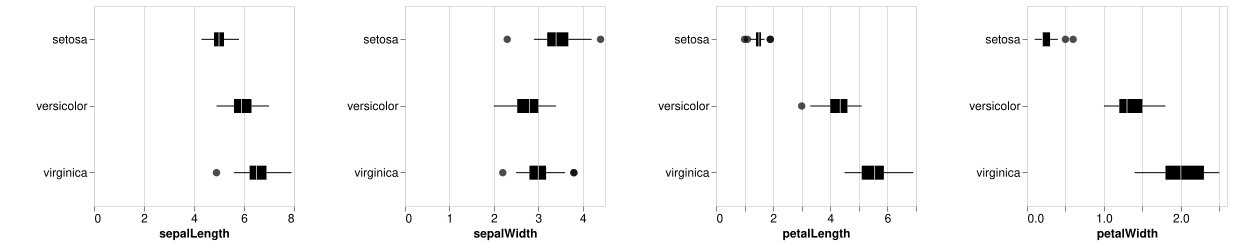

In [203]:
# explore relationship between categorcal and numerical columns
catergorical_columns = iris_dataset.select_dtypes(include=['object']).columns.to_list()
numerical_columns = iris_dataset.select_dtypes(include=['number']).columns.to_list()

(
    alt.Chart(iris_dataset)
    .mark_boxplot()
    .encode(
        y=alt.Y('species:N', title=''),
        x=alt.X(alt.repeat('column'), type='quantitative'),
    )
    .properties(width=200, height=200)
    .repeat(
        column=numerical_columns,
    )

)

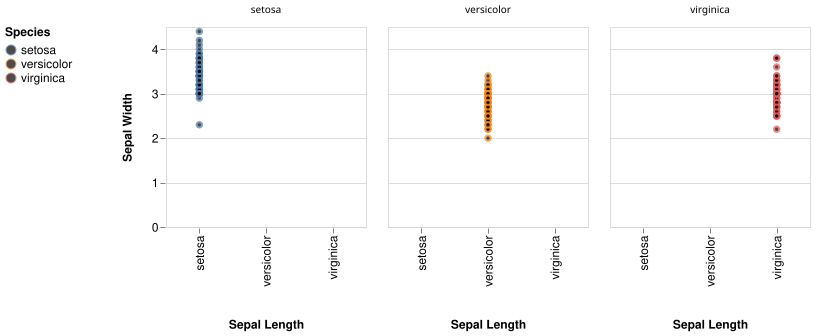

In [204]:
(
    alt.Chart(iris_dataset)
    .mark_point()
    .encode(
        x=alt.X('species:N', title='Sepal Length'),
        y=alt.Y('sepalWidth:Q', title='Sepal Width'),
        color=alt.Color('species:N', title='Species', legend=alt.Legend(orient='left')),
        column=alt.Column('species:N', title=''),
    )
    .properties(width=200, height=200)
)


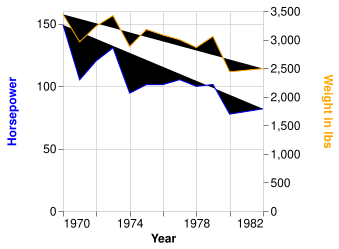

In [205]:
import altair as alt
import pandas as pd

# Assuming cars_data is a DataFrame and it already contains the necessary columns

# Create the horsepower line chart
horsepower_line = (
    alt.Chart(cars_data)
    .encode(
        x=alt.X('Year:T'),
        y=alt.Y(
            'Horsepower:Q',
            axis=alt.Axis(title='Horsepower', titleColor='blue'),  # Set title color
            aggregate='mean'
        )
    )
    .mark_line(color='blue')  # Line color
)

# Create the weight line chart
weight_line = (
    alt.Chart(cars_data)
    .encode(
        x=alt.X('Year:T'),
        y=alt.Y(
            'Weight_in_lbs:Q',
            axis=alt.Axis(title='Weight in lbs', titleColor='orange'),  # Set title color
            aggregate='mean'
        )
    )
    .mark_line(color='orange')  # Line color
)

# Combine the two charts with independent y-axes
chart = alt.layer(horsepower_line, weight_line).resolve_scale(y='independent')

chart



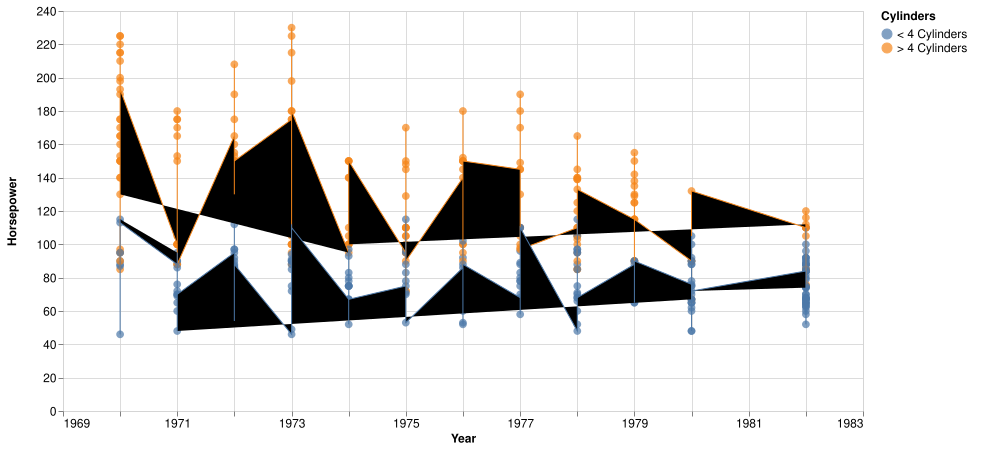

In [206]:

# Assuming cars_data is a DataFrame
cars_data['Cylinders_Category'] = np.where(cars_data['Cylinders'] > 4, '> 4 Cylinders', '< 4 Cylinders')

# Create the scatter plot
scatter_plot = (
    alt.Chart(cars_data)
    .mark_circle(size=60)  # Adjust size as needed
    .encode(
        x=alt.X('Year:T', title='Year', scale=alt.Scale(domain=['1969', '1983'])),
        y=alt.Y('Horsepower:Q', title='Horsepower'),
        color=alt.Color('Cylinders_Category:N', title='Cylinders'),
        tooltip=['Name:N', 'Cylinders:N']
    )
    .properties(
        width=800,
        height=400
    )


)

scatter_plot + scatter_plot.mark_line().encode(y=alt.Y('Horsepower:Q', aggregate='mean'))



In [207]:
cars_data.head()

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin,Cylinders_Category
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA,> 4 Cylinders
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA,> 4 Cylinders
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA,> 4 Cylinders
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA,> 4 Cylinders
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA,> 4 Cylinders


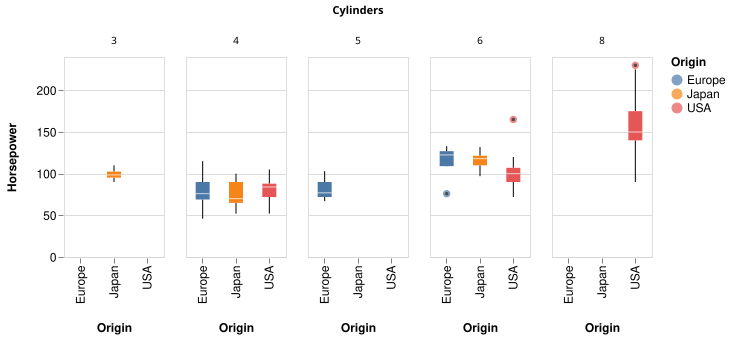

In [208]:
box = (
    alt.Chart(cars_data)
    .mark_boxplot()
    .encode(
        x=alt.X('Origin:N', ),
        y=alt.Y('Horsepower:Q', ),
        color=alt.Color('Origin:N'),
        column=alt.Column('Cylinders:N', ),
    )
    .interactive()
    .properties(width=100, height=200)
)

box

In [209]:
import plotly.express as px
import pandas as pd

fig = px.box(
    cars_data,
    x='Origin',
    y='Horsepower',
    color='Origin',
    title='Box Plot of Horsepower by Origin and Cylinders',
    facet_col='Cylinders',
    points='all',
    hover_data=['Name', 'Cylinders'],
    width=800
)

fig.update_layout(template='none')
fig.update_traces(marker_size=4, jitter=0.6,)

fig.show()

In [210]:
url = 'https://www.bbc.co.uk/sport/football/premier-league/table'

premier_league_data = pd.read_html(url)[0]

split_last_6_games = (
    premier_league_data.rename(columns={'Form, Last 6 games, Oldest first': 'last_six_results'})
    ['last_six_results']
    .str.replace('Result', '')
    .str.replace('Win', '')
    .str.replace('Loss', '')
    .str.replace('Draw', '')
    .str.split(' ', expand=True)
    # Rename the columns of split_last_6_games to strings
    .rename(columns=lambda x: f'last_six_{x}')
)

premier_league_table = (
    premier_league_data.drop(columns=['Form, Last 6 games, Oldest first'])
    .join(split_last_6_games)
)

# inspect the data
premier_league_table.head()

,Team,Played,Won,Drawn,Lost,Goals For,Goals Against,Goal Difference,Points,last_six_0,last_six_1,last_six_2,last_six_3,last_six_4,last_six_5,last_six_6
0,1Liverpool,5,5,0,0,11,5,6,15,No,W,W,W,W,W,
1,2Arsenal,5,3,1,1,10,2,8,10,No,W,W,L,W,D,
2,3Tottenham Hotspur,5,3,1,1,10,3,7,10,No,W,W,L,W,D,
3,4AFC Bournemouth,5,3,1,1,6,5,1,10,No,L,W,W,W,D,
4,5Crystal Palace,5,2,3,0,6,2,4,9,No,D,D,W,D,W,


In [211]:
premier_league_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Team             20 non-null     object
 1   Played           20 non-null     int64 
 2   Won              20 non-null     int64 
 3   Drawn            20 non-null     int64 
 4   Lost             20 non-null     int64 
 5   Goals For        20 non-null     int64 
 6   Goals Against    20 non-null     int64 
 7   Goal Difference  20 non-null     int64 
 8   Points           20 non-null     int64 
 9   last_six_0       20 non-null     object
 10  last_six_1       20 non-null     object
 11  last_six_2       20 non-null     object
 12  last_six_3       20 non-null     object
 13  last_six_4       20 non-null     object
 14  last_six_5       20 non-null     object
 15  last_six_6       20 non-null     object
dtypes: int64(8), object(8)
memory usage: 2.6+ KB


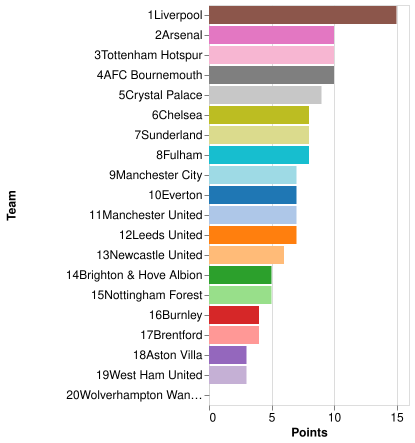

In [212]:
bar = (
    alt.Chart(premier_league_table)
    .mark_bar()
    .encode(
      y=alt.Y('Team:N', title='Team', sort='-x'),
      x=alt.X('Points:Q', title='Points',),
      color=alt.Color('Team:N', title='Team', legend=None, scale=alt.Scale(scheme='category20')),
    )
)

bar

/tmp/ipython-input-782240183.py:3: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.

/tmp/ipython-input-782240183.py:24: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.



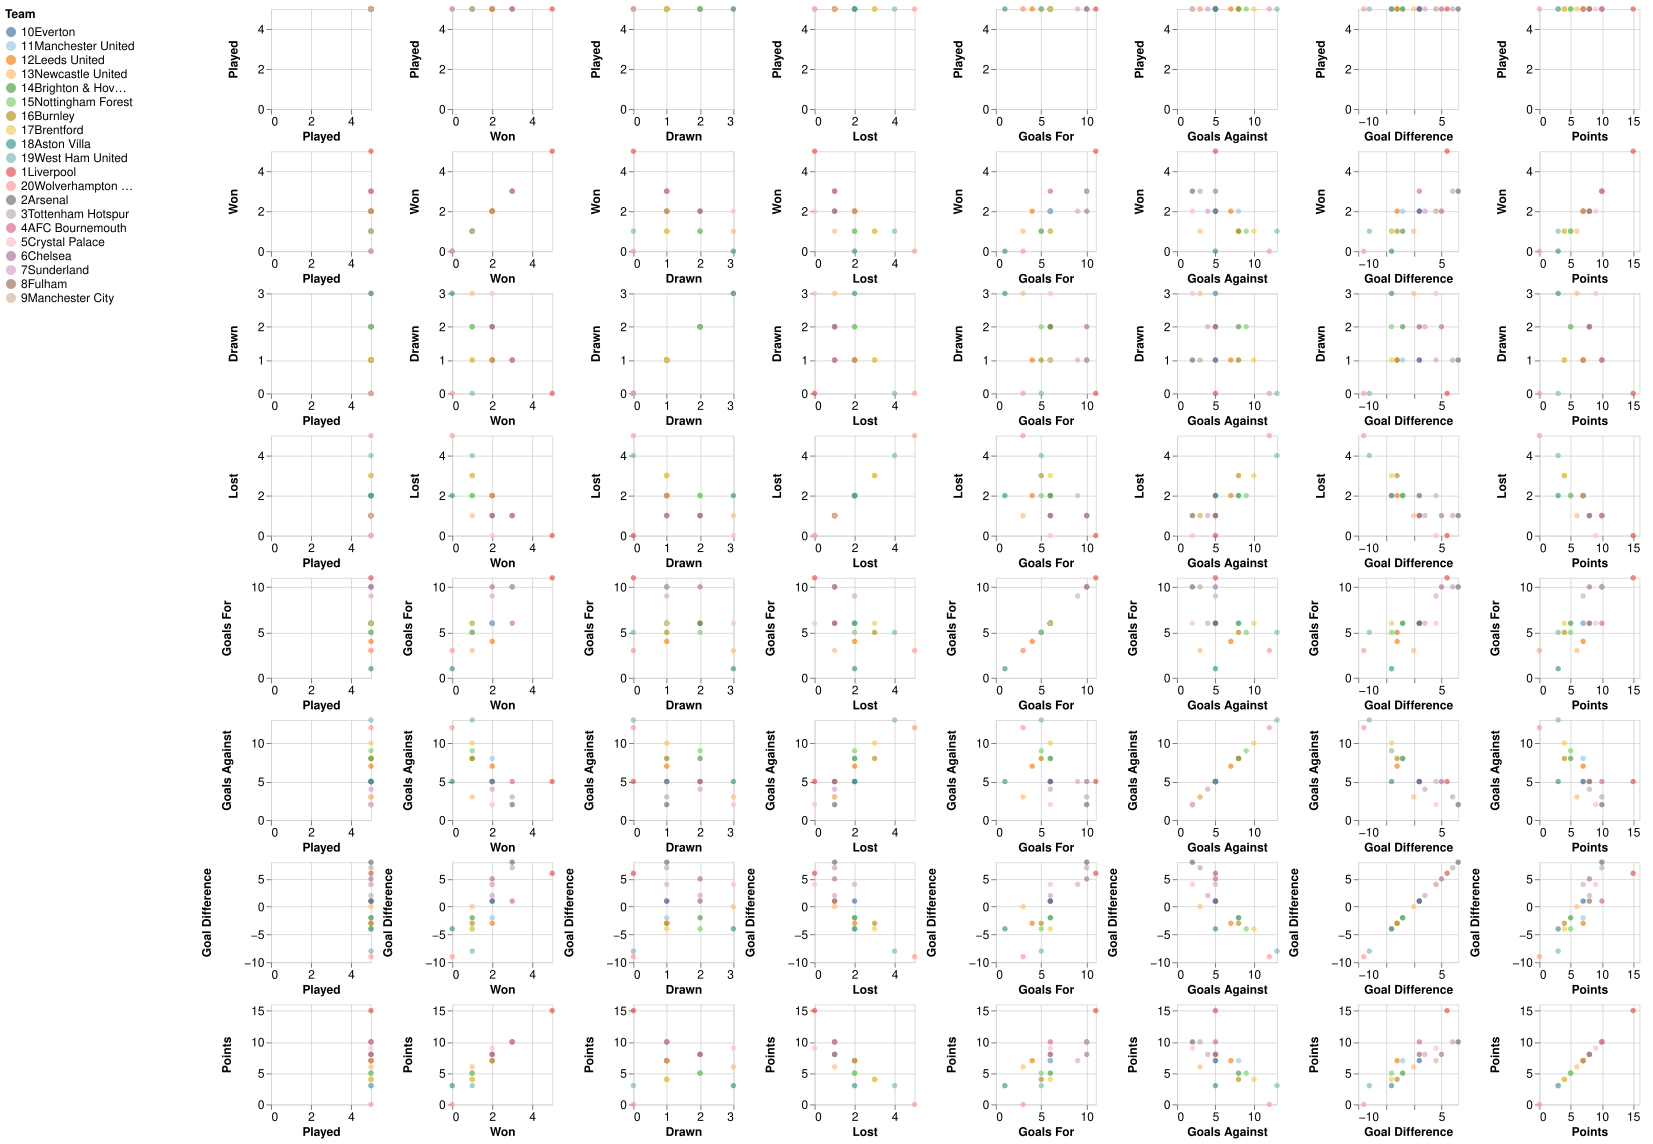

In [213]:
# create a scatter matrix

brush = alt.selection(type='interval')
# brush = alt.selection_interval(resolve='intersect')

numerical_data_columns = premier_league_table.select_dtypes(include=['number']).columns.to_list()

chart = (
    alt.Chart(premier_league_table)
    .mark_circle(size=30)
    .encode(
        x=alt.X(alt.repeat('column'), type='quantitative'),
        y=alt.Y(alt.repeat('row'), type='quantitative'),
        color=alt.condition(brush, 'Team:N', alt.value('lightgrey'), legend=alt.Legend(orient='left'), scale=alt.Scale(scheme='tableau20')),
        # color=alt.Color('Team:N', legend=alt.Legend(orient='left')), # removed tooltip from here
        tooltip=[ # added tooltip encoding here
            alt.Tooltip('Team:N', title='Team'),
            alt.Tooltip(alt.repeat('column'), type='quantitative'),
            alt.Tooltip(alt.repeat('row'), type='quantitative')
        ]
    )
    .properties(width=100, height=100)
    .repeat(column=numerical_data_columns, row=numerical_data_columns, spacing=0.2)
    .add_selection(brush)
)

chart

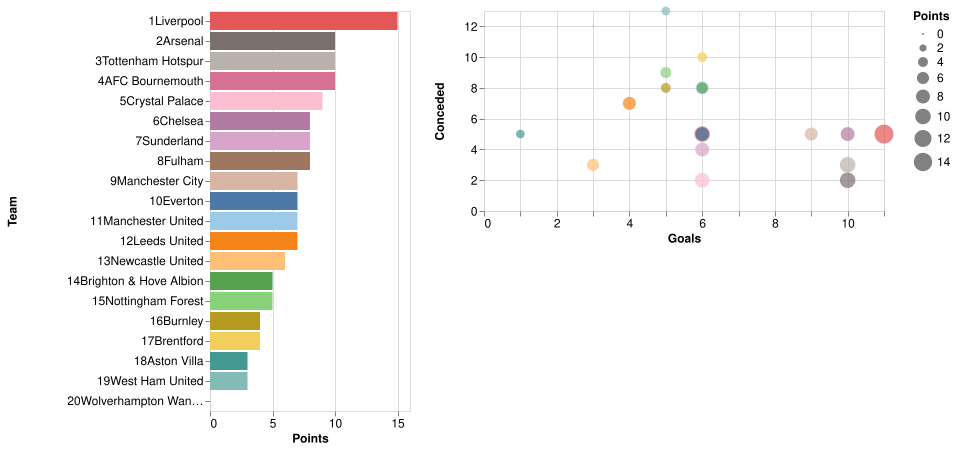

In [214]:
import altair as alt

point = (
    alt.Chart(premier_league_table)
    .mark_circle()
    .encode(
        x=alt.X('Goals For:Q', axis=alt.Axis(title='Goals')),
        y=alt.Y('Goals Against:Q', axis=alt.Axis(title='Conceded')),
        size=alt.Size('Points:Q', legend=alt.Legend(orient='right')),
        color=alt.Color('Team:N', legend=None, scale=alt.Scale(scheme='tableau20')),
        tooltip=[
            alt.Tooltip('Team:N', title='Team'),
            alt.Tooltip('Goals For:Q', title='Goals For'),
            alt.Tooltip('Goals Against:Q', title='Goals Against'),
            alt.Tooltip('Points:Q', title='Points')
        ]
    )
    .properties(width=400, height=200)
)

bar = (
    alt.Chart(premier_league_table)
    .mark_bar()
    .encode(
        y=alt.Y('Team:N', title='Team', sort='-x'),
        x=alt.X('Points:Q', title='Points'),
        color=alt.Color('Team:N', title='Team', legend=None, scale=alt.Scale(scheme='tableau20')),
    )
)

# Combine the point and bar charts
(bar | point).resolve_scale(color='independent')



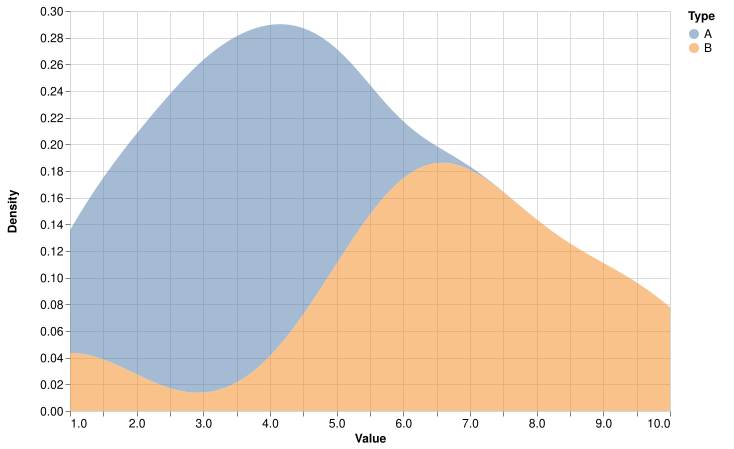

In [215]:
import altair as alt
import pandas as pd

# Sample DataFrame (replace with your actual data)
data = pd.DataFrame({
    'value': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 3, 4, 5, 6, 7, 2, 3, 4, 5, 1],
    'type': ['A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'B']
})

# KDE plot with color by 'type'
kde_plot = (
    alt.Chart(data)
    .transform_density(
        density='value',
        groupby=['type'],
        as_=['value', 'density']
    )
    .mark_area(opacity=0.5)
    .encode(
        x=alt.X('value:Q', title='Value'),
        y=alt.Y('density:Q', title='Density'),
        color=alt.Color('type:N', title='Type')
    )
    .properties(width=600, height=400)
)

kde_plot


In [216]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assuming cars_data is a DataFrame and it already contains the necessary columns

# Create a subplot with 2 y-axes
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add the horsepower line chart
fig.add_trace(
    go.Scatter(
        x=cars_data['Year'],
        y=cars_data['Horsepower'],
        mode='lines',
        name='Horsepower',
        line=dict(color='blue')
    ),
    secondary_y=False  # Use the primary y-axis
)

# Add the weight line chart
fig.add_trace(
    go.Scatter(
        x=cars_data['Year'],
        y=cars_data['Weight_in_lbs'],
        mode='lines',
        name='Weight in lbs',
        line=dict(color='orange')
    ),
    secondary_y=True  # Use the secondary y-axis
)

# Update layout to customize axes titles and colors
fig.update_layout(
    title='Horsepower and Weight Over Years',
    xaxis_title='Year',
    yaxis_title='Horsepower',
    yaxis2=dict(title='Weight in lbs', titlefont=dict(color='orange'), overlaying='y', side='right'),
    yaxis=dict(title='Horsepower', titlefont=dict(color='blue')),
    width=800,
    height=400
)

# Show the figure
fig.show()


In [217]:
import polars as pl

# convert to polars dataframe
cars = pl.from_pandas(cars_data)

cars.head()

Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin,Cylinders_Category
str,f64,i64,f64,f64,i64,f64,datetime[ns],str,str
"""chevrolet chevelle malibu""",18.0,8,307.0,130.0,3504,12.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""buick skylark 320""",15.0,8,350.0,165.0,3693,11.5,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""plymouth satellite""",18.0,8,318.0,150.0,3436,11.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""amc rebel sst""",16.0,8,304.0,150.0,3433,12.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""ford torino""",17.0,8,302.0,140.0,3449,10.5,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""


In [218]:
cars_long = (
    cars
    .select(pl.selectors.exclude('Cylinders_Category'))
    .unpivot(
        index=['Name', 'Cylinders', 'Origin', 'Year'],
    )
    .filter(pl.col('variable').is_in(['Miles_per_Gallon', 'Horsepower', 'Acceleration', 'Weight_in_lbs']))
)

cars_long.head()

Name,Cylinders,Origin,Year,variable,value
str,i64,str,datetime[ns],str,f64
"""chevrolet chevelle malibu""",8,"""USA""",1970-01-01 00:00:00,"""Miles_per_Gallon""",18.0
"""buick skylark 320""",8,"""USA""",1970-01-01 00:00:00,"""Miles_per_Gallon""",15.0
"""plymouth satellite""",8,"""USA""",1970-01-01 00:00:00,"""Miles_per_Gallon""",18.0
"""amc rebel sst""",8,"""USA""",1970-01-01 00:00:00,"""Miles_per_Gallon""",16.0
"""ford torino""",8,"""USA""",1970-01-01 00:00:00,"""Miles_per_Gallon""",17.0


In [219]:
cars.head()

Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin,Cylinders_Category
str,f64,i64,f64,f64,i64,f64,datetime[ns],str,str
"""chevrolet chevelle malibu""",18.0,8,307.0,130.0,3504,12.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""buick skylark 320""",15.0,8,350.0,165.0,3693,11.5,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""plymouth satellite""",18.0,8,318.0,150.0,3436,11.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""amc rebel sst""",16.0,8,304.0,150.0,3433,12.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""ford torino""",17.0,8,302.0,140.0,3449,10.5,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""


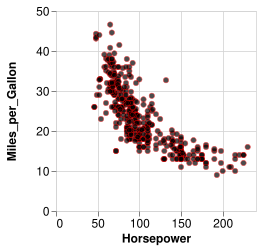

In [220]:
(
    alt.Chart(cars)
    # .mark_point(filled=True, size=20)
    .mark_point(strokeWidth=0.5, color='red')
    .encode(
        alt.X('Horsepower:Q'),
        y='Miles_per_Gallon:Q',
        # color=alt.Color('Cylinders:N').scale(domain=[3, 4, 8]),
        # color=alt.Color('Cylinders:N').scale(scheme='category10'),
        # column='Cylinders:N',
        # stroke=alt.Color('Cylinders:N')
    )
    .properties(
        width=200
    )
)

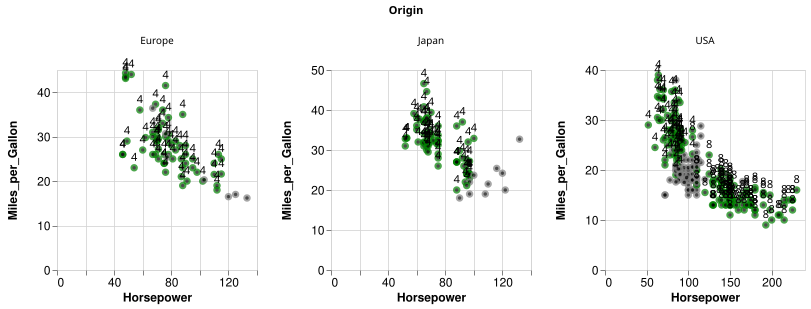

In [221]:
base = alt.Chart(cars)

points = base.mark_point().encode(
    x=alt.X('Horsepower:Q'),
    y=alt.Y('Miles_per_Gallon:Q'),
    stroke=alt.condition(
        (alt.datum.Cylinders == 4) | (alt.datum.Cylinders == 8),
        alt.value('green'),
        alt.value('grey')
    ),
)

text = base.mark_text(
    align='center',
    baseline='middle',
    dy=-10  # Offset text above points
).encode(
    x=alt.X('Horsepower:Q'),
    y=alt.Y('Miles_per_Gallon:Q'),
    text=alt.condition(
        (alt.datum.Cylinders == 4) | (alt.datum.Cylinders == 8),
        alt.Text('Cylinders:N'),  # Show cylinder count
        alt.value('')             # No text for others
    ),
)

(points + text).facet(
    column='Origin:N'
).resolve_scale(
    x='independent',
    y='independent'
)

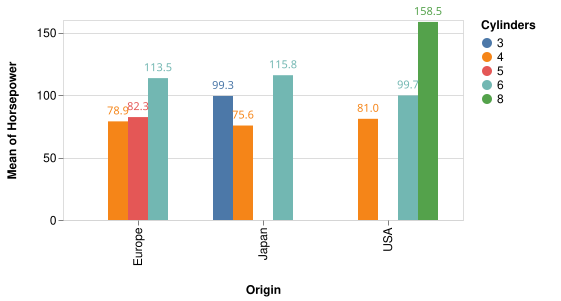

In [222]:
base = alt.Chart(cars).encode(
    alt.X('Origin:O'),
    alt.Color('Cylinders:N'),
    alt.XOffset('Cylinders:N')
)

bars = base.mark_bar().encode(
    alt.Y('Horsepower:Q', aggregate='mean')
)

text = base.mark_text(
    align='center',
    baseline='bottom',
    dy=-5  # Offset text slightly above bars
).encode(
    alt.Y('Horsepower:Q', aggregate='mean'),
    alt.Text('Horsepower:Q', aggregate='mean', format='.1f')  # Format to 1 decimal
)

chart = bars + text
chart

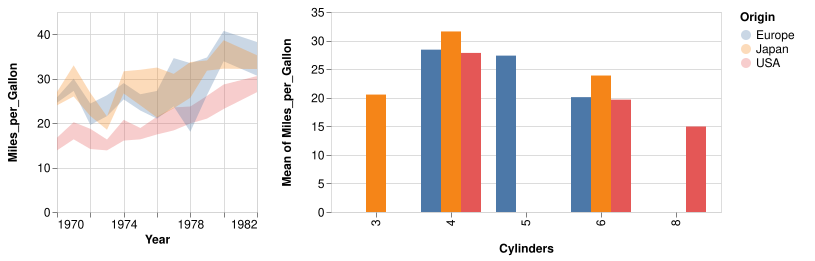

In [223]:
line = (
    alt.Chart(cars)
    .mark_bar()
    .encode(
        x=alt.X('Cylinders:N'),
        y=alt.Y('Miles_per_Gallon:Q', aggregate='mean'),
        color=alt.Color('Origin:N'),
        xOffset=alt.XOffset('Origin:N')

    )
)

band = (
    alt.Chart(cars)
    .mark_errorband(extent='ci')
    .encode(
        x='Year:T',
        y='Miles_per_Gallon',
        color='Origin:N'
    )

)

(band | line)

In [224]:
cars.head(2)

Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin,Cylinders_Category
str,f64,i64,f64,f64,i64,f64,datetime[ns],str,str
"""chevrolet chevelle malibu""",18.0,8,307.0,130.0,3504,12.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""buick skylark 320""",15.0,8,350.0,165.0,3693,11.5,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""


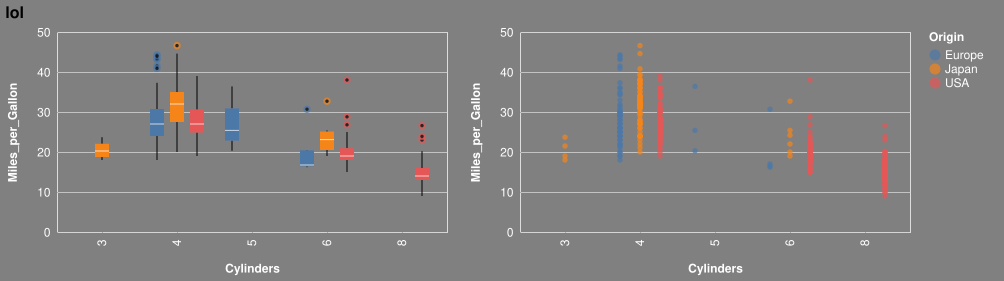

In [225]:
box = (
    alt.Chart(cars)
    .mark_boxplot()
    .encode(
        x=alt.X('Cylinders:O'),
        y=alt.Y('Miles_per_Gallon:Q'),
        color=alt.Color('Origin:N'),
        xOffset=alt.XOffset('Origin:N')
    )
)

point = (
    alt.Chart(cars)
    .mark_circle()
    .encode(
        x=alt.X('Cylinders:O'),
        y=alt.Y('Miles_per_Gallon:Q'),
        color=alt.Color('Origin:N'),
        xOffset=alt.XOffset('Origin:N',)
    )
)

# Using HConcatChart explicitly
# Using hconcat helper
chart = alt.hconcat(
    box,
    point, title='lol', autosize='pad', background='grey'
).configure_axis(
    labelColor='white',
    titleColor='white'
).configure_legend(
    labelColor='white',
    titleColor='white'
)

chart

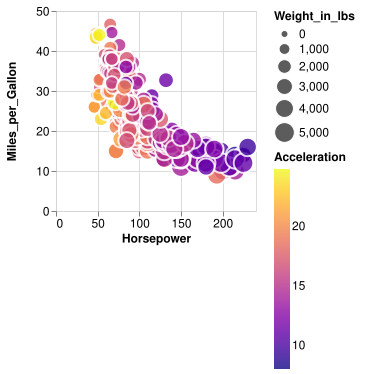

In [226]:
alt.Chart(cars).mark_circle(
    size=200,
    opacity=0.8,
    stroke='white',
    strokeWidth=2
).encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    fill=alt.Fill('Acceleration:Q').scale(scheme='plasma'),
    size=alt.Size('Weight_in_lbs:Q').scale(range=[50, 400])
)

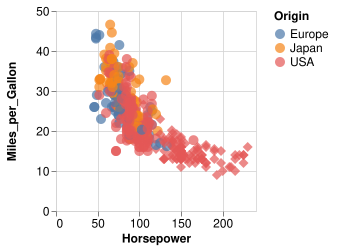

In [227]:
alt.Chart(cars).mark_point(
    filled=True,
    size=100
).encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    shape=alt.condition(
        alt.datum.Cylinders > 6,
        alt.value('diamond'),
        alt.value('circle')
    ),
    color='Origin:N'
)

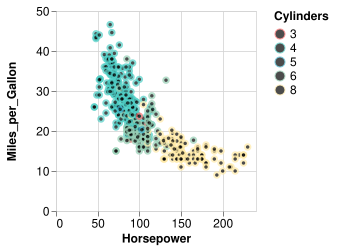

In [228]:
alt.Chart(cars).mark_point().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color=alt.Color('Cylinders:O').scale(
        domain=[3, 4, 5, 6, 8],
        range=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    )
)

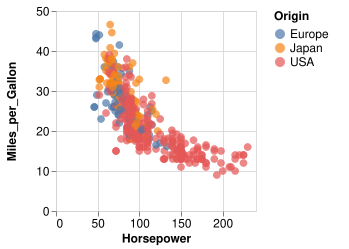

In [229]:
alt.Chart(cars).mark_circle(size=60).encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color='Origin:N',
    tooltip=[
        alt.Tooltip('Name:N', title='Car Model'),
        alt.Tooltip('Horsepower:Q', title='HP', format='.0f'),
        alt.Tooltip('Miles_per_Gallon:Q', title='MPG', format='.1f'),
        alt.Tooltip('Acceleration:Q', title='0-60 mph', format='.1f')
    ]
).interactive()

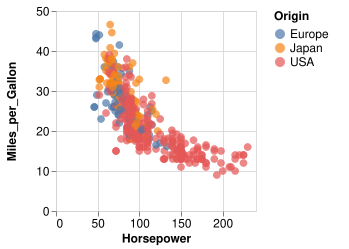

In [230]:
alt.Chart(cars).mark_circle(size=60).encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color='Origin:N',
    tooltip=[
        alt.Tooltip('Name:N', title='Car Model'),
        alt.Tooltip('Horsepower:Q', title='HP', format='.0f'),
        alt.Tooltip('Miles_per_Gallon:Q', title='MPG', format='.1f'),
        alt.Tooltip('Acceleration:Q', title='0-60 mph', format='.1f')
    ]
).interactive()

/tmp/ipython-input-4062499489.py:9: AltairDeprecationWarning:


Deprecated since `altair=5.0.0`. Use add_params instead.



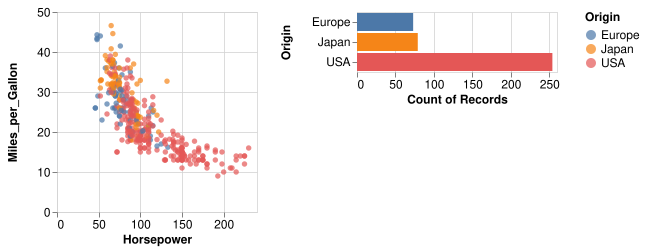

In [231]:
brush = alt.selection_interval()

base = alt.Chart(cars)

scatter = base.mark_circle().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color=alt.condition(brush, 'Origin:N', alt.value('lightgray'))
).add_selection(brush)

hist = base.mark_bar().encode(
    x='count()',
    y='Origin:N',
    color='Origin:N'
).transform_filter(brush)

scatter | hist

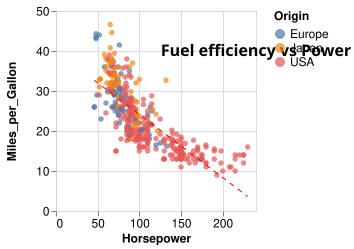

In [232]:
base = alt.Chart(cars)

points = base.mark_circle().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color='Origin:N'
)

# Add trend line
line = base.mark_line(color='red', strokeDash=[5,5]).transform_regression(
    'Horsepower', 'Miles_per_Gallon'
).encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q'
)

# Add text annotations
text = alt.Chart({'values': [{}]}).mark_text(
    text='Fuel efficiency vs Power',
    x=200, y=40,
    fontSize=16,
    fontWeight='bold'
)

points + line + text

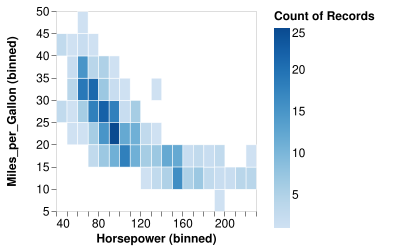

In [233]:
alt.Chart(cars).mark_rect().encode(
    x=alt.X('Horsepower:Q').bin(maxbins=20),
    y=alt.Y('Miles_per_Gallon:Q').bin(maxbins=15),
    color=alt.Color('count():Q').scale(scheme='blues'),
    stroke=alt.value('white'),
    strokeWidth=alt.value(0.5)
)

In [234]:
# Plotly Express approach
import plotly.express as px
import pandas as pd
import numpy as np

# Create 2D histogram data

fig = px.density_heatmap(
    cars,
    x='Horsepower',
    y='Miles_per_Gallon',
    nbinsx=20,        # equivalent to maxbins=20
    nbinsy=15,        # equivalent to maxbins=15
    color_continuous_scale='Blues',  # equivalent to scheme='blues'
    title='2D Histogram Heatmap',
    text_auto='.1f'
)

# Add white gridlines (stroke equivalent)
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='white', gridwidth=0.5),
    yaxis=dict(showgrid=True, gridcolor='white', gridwidth=0.5)
)

fig.show(

)

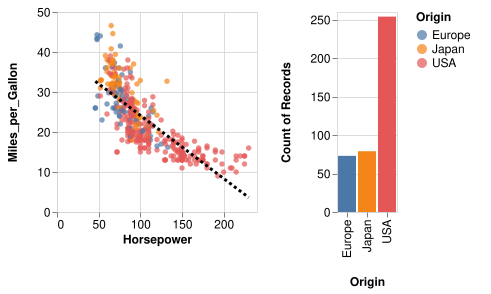

In [235]:
brush = alt.selection_interval(resolve='global')

base = alt.Chart(cars).encode(
    alt.X('Horsepower:Q'),
    alt.Y('Miles_per_Gallon:Q')
)

circle = base.mark_circle().encode(
    color=alt.condition(brush, 'Origin:N', alt.value('lightgray'))
).add_params(brush)

lr = base.transform_regression('Horsepower', 'Miles_per_Gallon').mark_line(color='black', strokeDash=[3,3], strokeWidth=3)

hist = base.mark_bar().encode(
    y='count()',
    x='Origin:N',
    color='Origin:N'
).transform_filter(brush)


alt.layer(circle, lr) | hist


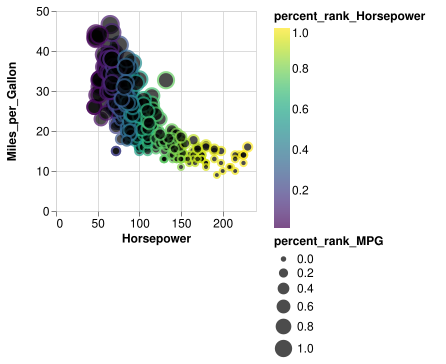

In [236]:
alt.Chart(cars).mark_point().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color=alt.Color('percent_rank_Horsepower:Q').scale(scheme='viridis'),
    size=alt.Size('percent_rank_MPG:Q').scale(range=[30, 300])
).transform_window(
    percent_rank_Horsepower='percent_rank()',
    sort=[alt.SortField('Horsepower')],
    frame=[None, None]
).transform_window(
    percent_rank_MPG='percent_rank()',
    sort=[alt.SortField('Miles_per_Gallon')],
    frame=[None, None]
)

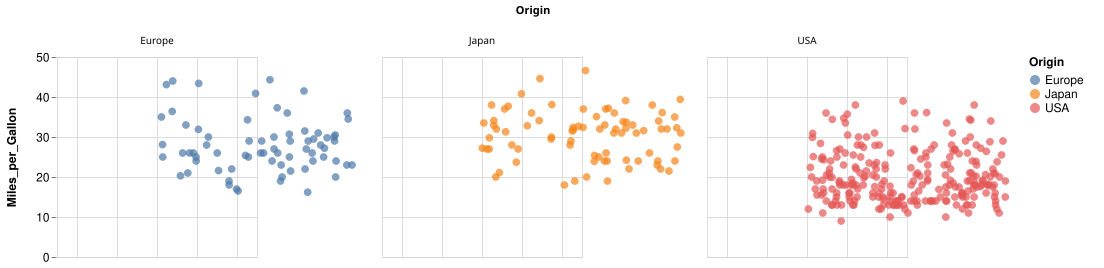

In [237]:
alt.Chart(cars).mark_circle(size=60).encode(
    x=alt.X('jitter:Q').scale(domain=[-0.5, 0.5]).axis(labels=False, ticks=False, title=''),
    y='Miles_per_Gallon:Q',
    color='Origin:N',
    column='Origin:N'
).transform_calculate(
    jitter='random()'
)

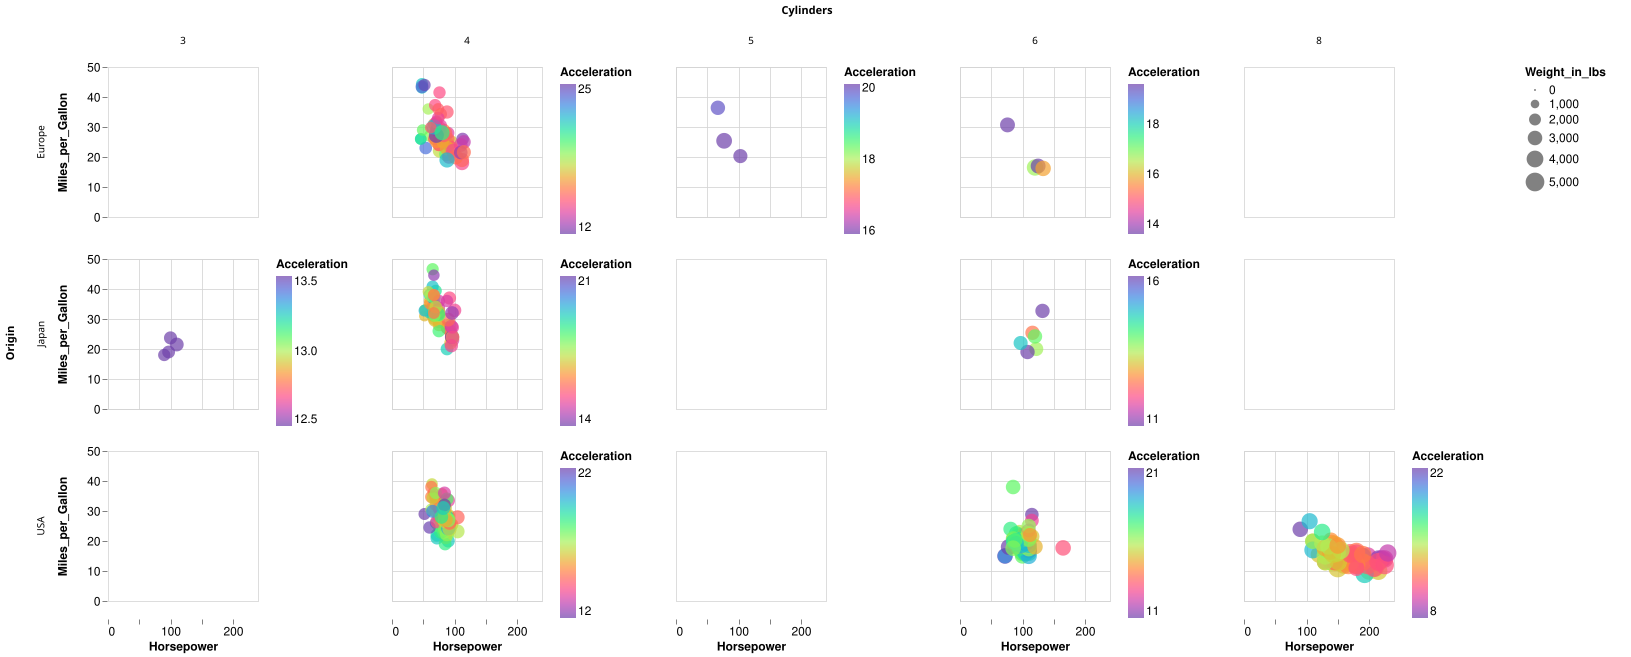

In [238]:
alt.Chart(cars).mark_circle().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color=alt.Color('Acceleration:Q').scale(scheme='rainbow'),
    size='Weight_in_lbs:Q'
).properties(
    width=150,
    height=150
).facet(
    row='Origin:N',
    column=alt.Column('Cylinders:O').header(labelAngle=0)
).resolve_scale(
    color='independent'
)

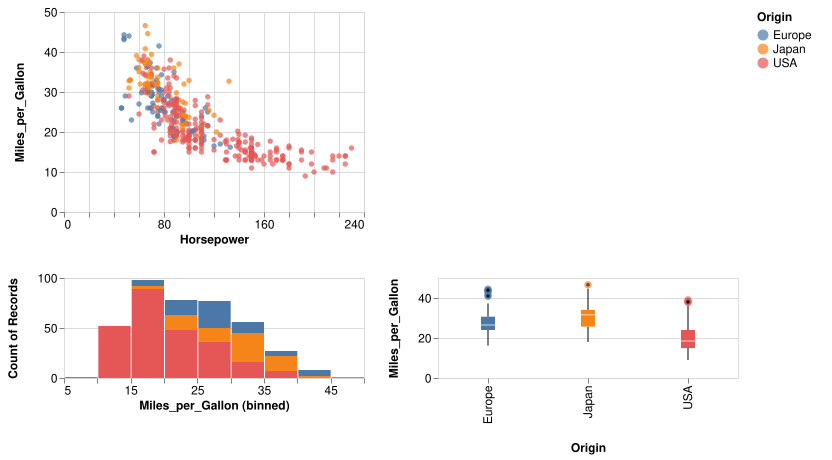

In [239]:
scatter = alt.Chart(cars).mark_circle().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color='Origin:N'
).properties(width=300, height=200)

histogram = alt.Chart(cars).mark_bar().encode(
    x=alt.X('Miles_per_Gallon:Q').bin(),
    y='count()',
    color='Origin:N'
).properties(width=300, height=100)

boxplot = alt.Chart(cars).mark_boxplot().encode(
    x='Origin:N',
    y='Miles_per_Gallon:Q',
    color='Origin:N'
).properties(width=300, height=100)

alt.vconcat(
    scatter,
    alt.hconcat(histogram, boxplot)
)

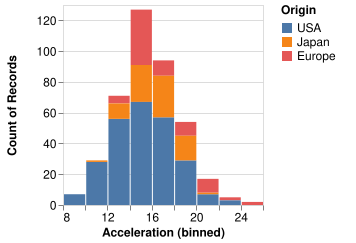

In [240]:
(
    alt.Chart(cars).mark_bar().encode(
      alt.X('Acceleration:Q', bin=True),
      alt.Y('count():Q'),
      alt.Color('Origin:N', sort = 'descending')
)
)

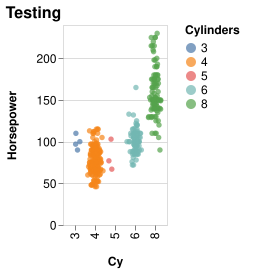

In [241]:
(
    alt.Chart(cars, title='Testing')
    .mark_circle()
    .encode(
        alt.X('Cylinders:N', title='Cy'),
        alt.Y('Horsepower:Q'),
        alt.Color('Cylinders:N'),
        xOffset='jitter:Q',
    )
    .transform_calculate(
        jitter='sqrt(-2*log(random())) *cos(2*PI*random())'
    )
    # .transform_filter(
    #     (alt.datum.Cylinders == 5) | # quick filtering
    #     (alt.datum.Cylinders == 8)
    # )

)

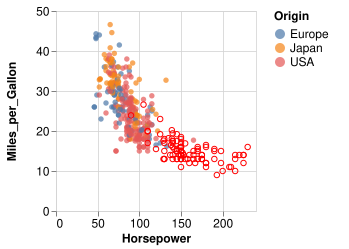

In [242]:
base = (
    alt.Chart(cars)
    .mark_circle()
    .encode(
        alt.X('Horsepower:Q'),
        alt.Y('Miles_per_Gallon:Q'),
        alt.Color('Origin:N')
    )
    .transform_filter(
        (alt.datum.Cylinders <= 6)
    )
)

cylinders8 = (
    alt.Chart(cars)
    .mark_point(color='red', strokeWidth=1, shape='circle', filled=False, fillOpacity=0)
    .encode(
        alt.X('Horsepower:Q'),
        alt.Y('Miles_per_Gallon:Q'),
    )
    .transform_filter(
        (alt.datum.Cylinders == 8)
    )
)

alt.layer(base, cylinders8)

In [243]:
cars_corr = cars.select(pl.selectors.numeric()).corr()

cars_corr

Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration
f64,f64,f64,f64,f64,f64
NaN,NaN,NaN,NaN,NaN,NaN
NaN,1.0,0.951787,NaN,0.89522,-0.522452
NaN,0.951787,1.0,NaN,0.932475,-0.557984
NaN,NaN,NaN,NaN,NaN,NaN
NaN,0.89522,0.932475,NaN,1.0,-0.430086
NaN,-0.522452,-0.557984,NaN,-0.430086,1.0


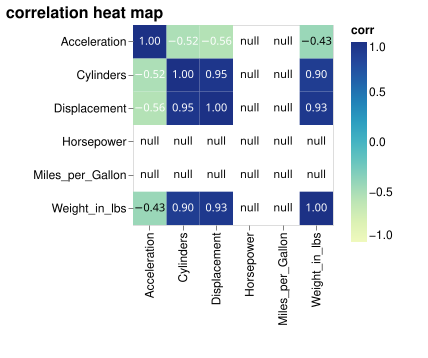

In [244]:
import polars as pl
import altair as alt

# Select numeric cols and compute correlation matrix
num_df = cars.select(pl.selectors.numeric())
corr_df = num_df.corr()

# corr_df is a square matrix with colnames = rownames
# Melt to long form
corr_long = corr_df.with_columns(row=pl.Series(num_df.columns)).unpivot(
    index="row", variable_name="col", value_name="corr"
)

# Altair heatmap + labels
heatmap = alt.Chart(corr_long, title='correlation heat map').mark_rect().encode(
    x=alt.X("col:O", title=""),
    y=alt.Y("row:O", title=""),
    color=alt.Color("corr:Q", scale=alt.Scale(domain=(-1, 1)))
)

text = alt.Chart(corr_long).mark_text(baseline="middle").encode(
    x="col:O",
    y="row:O",
    text=alt.Text("corr:Q", format=".2f"),
    color=alt.condition(
        "datum.corr > 0.5 || datum.corr < -0.5",
        alt.value("white"),
        alt.value("black")
    )
)

chart = heatmap + text
chart.properties(width=200, height=200)


In [245]:
corr_df.with_columns(row=pl.Series(num_df.columns))

Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,row
f64,f64,f64,f64,f64,f64,str
NaN,NaN,NaN,NaN,NaN,NaN,"""Miles_per_Gallon"""
NaN,1.0,0.951787,NaN,0.89522,-0.522452,"""Cylinders"""
NaN,0.951787,1.0,NaN,0.932475,-0.557984,"""Displacement"""
NaN,NaN,NaN,NaN,NaN,NaN,"""Horsepower"""
NaN,0.89522,0.932475,NaN,1.0,-0.430086,"""Weight_in_lbs"""
NaN,-0.522452,-0.557984,NaN,-0.430086,1.0,"""Acceleration"""


In [246]:
corr_long

row,col,corr
str,str,f64
"""Miles_per_Gallon""","""Miles_per_Gallon""",NaN
"""Cylinders""","""Miles_per_Gallon""",NaN
"""Displacement""","""Miles_per_Gallon""",NaN
"""Horsepower""","""Miles_per_Gallon""",NaN
"""Weight_in_lbs""","""Miles_per_Gallon""",NaN
…,…,…
"""Cylinders""","""Acceleration""",-0.522452
"""Displacement""","""Acceleration""",-0.557984
"""Horsepower""","""Acceleration""",NaN


In [247]:
cars.select(pl.selectors.numeric(), 'Name', 'Origin').unpivot(index=['Name', 'Origin'] )

Name,Origin,variable,value
str,str,str,f64
"""chevrolet chevelle malibu""","""USA""","""Miles_per_Gallon""",18.0
"""buick skylark 320""","""USA""","""Miles_per_Gallon""",15.0
"""plymouth satellite""","""USA""","""Miles_per_Gallon""",18.0
"""amc rebel sst""","""USA""","""Miles_per_Gallon""",16.0
"""ford torino""","""USA""","""Miles_per_Gallon""",17.0
…,…,…,…
"""ford mustang gl""","""USA""","""Acceleration""",15.6
"""vw pickup""","""Europe""","""Acceleration""",24.6
"""dodge rampage""","""USA""","""Acceleration""",11.6


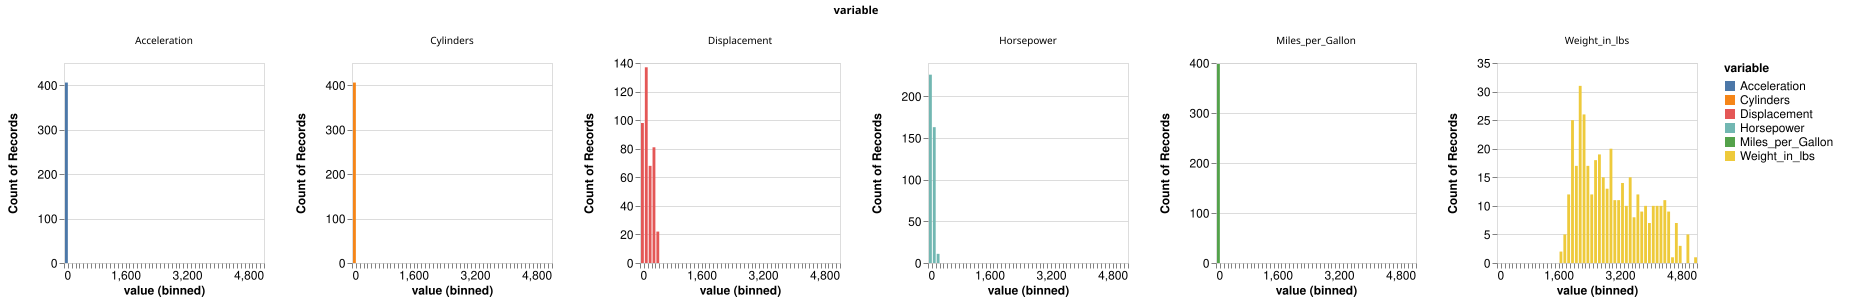

In [248]:
(
    alt.Chart(cars.select(pl.selectors.numeric(), 'Name').unpivot(index='Name', ))
    .mark_bar()
    .encode(
        alt.X('value:Q').bin(maxbins=100),      # bin numeric values
        alt.Y('count()').stack(None),           # raw counts
        alt.Color('variable:N'),                # color by variable
        column='variable:N'                     # facet: one histogram per variable
    )
    .resolve_scale(x='independent', y='independent')

)


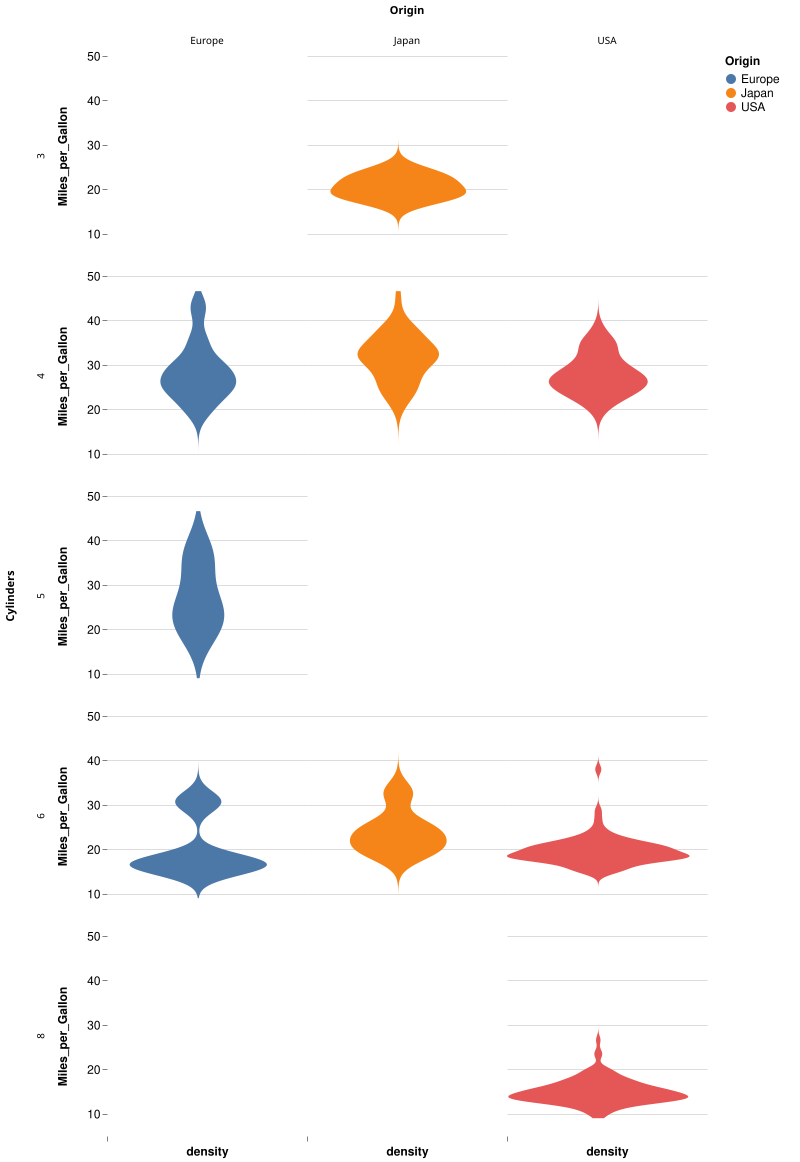

In [249]:
(
    alt.Chart(cars)
    .transform_density(
        'Miles_per_Gallon',
        as_=['Miles_per_Gallon', 'density'],
        groupby=['Origin', 'Cylinders']
    )
    .mark_area(orient='horizontal')
    .encode(
        alt.X('density:Q').stack('center').impute(None).axis(labels=False, values=[0], grid=False, ticks=True),
        alt.Y('Miles_per_Gallon:Q'),
        alt.Color('Origin'),
        alt.Column("Origin",).spacing(0),
        alt.Row('Cylinders')
    )
    .configure_view(
        stroke=None
    )
)

In [250]:
cars.head()

Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin,Cylinders_Category
str,f64,i64,f64,f64,i64,f64,datetime[ns],str,str
"""chevrolet chevelle malibu""",18.0,8,307.0,130.0,3504,12.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""buick skylark 320""",15.0,8,350.0,165.0,3693,11.5,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""plymouth satellite""",18.0,8,318.0,150.0,3436,11.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""amc rebel sst""",16.0,8,304.0,150.0,3433,12.0,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
"""ford torino""",17.0,8,302.0,140.0,3449,10.5,1970-01-01 00:00:00,"""USA""","""> 4 Cylinders"""
